In [6]:
import wrds
import pandas as pd
import matplotlib.pyplot as plt


In [7]:
db = wrds.Connection(wrds_username='wswsq')

Loading library list...
Done


In [8]:
query = """
    SELECT gvkey, datadate, fyear, conm,
           revt, ni, at, lt, act, lct
    FROM comp.funda
    WHERE tic = 'AAPL'
    AND indfmt = 'INDL'
    AND datafmt = 'STD'
    AND popsrc = 'D'
    AND consol = 'C'
    ORDER BY fyear;
"""
df = db.raw_sql(query)

In [9]:
db.close()

In [4]:
df = df.dropna()
df['datadate'] = pd.to_datetime(df['datadate'])
df = df.set_index('fyear')

df['profit_margin'] = df['ni'] / df['revt']
df['roa'] = df['ni'] / df['at']
df['current_ratio'] = df['act'] / df['lct']
df['debt_to_asset'] = df['lt'] / df['at']

print("=== Apple Financial Ratios (WRDS) ===")
print(df[['profit_margin','roa','current_ratio','debt_to_asset']].round(3))


=== Apple Financial Ratios (WRDS) ===
       profit_margin    roa  current_ratio  debt_to_asset
fyear                                                    
1980             0.1  0.179          1.432          0.603
1981           0.118  0.155          3.231          0.304
1982           0.105  0.171          3.697          0.281
1983           0.078  0.138          3.642          0.321
1984           0.042  0.081          2.694          0.411
1985           0.032  0.065          2.783          0.412
1986           0.081  0.133          3.168          0.402
1987           0.082  0.147          2.731          0.434
1988           0.098  0.192          2.156          0.518
1989           0.086  0.165          2.563          0.459
1990           0.085   0.16           2.34          0.514
1991           0.049  0.089          2.353          0.494
1992           0.075  0.126          2.496          0.482
1993           0.011  0.017          1.725          0.608
1994           0.034  0.058       

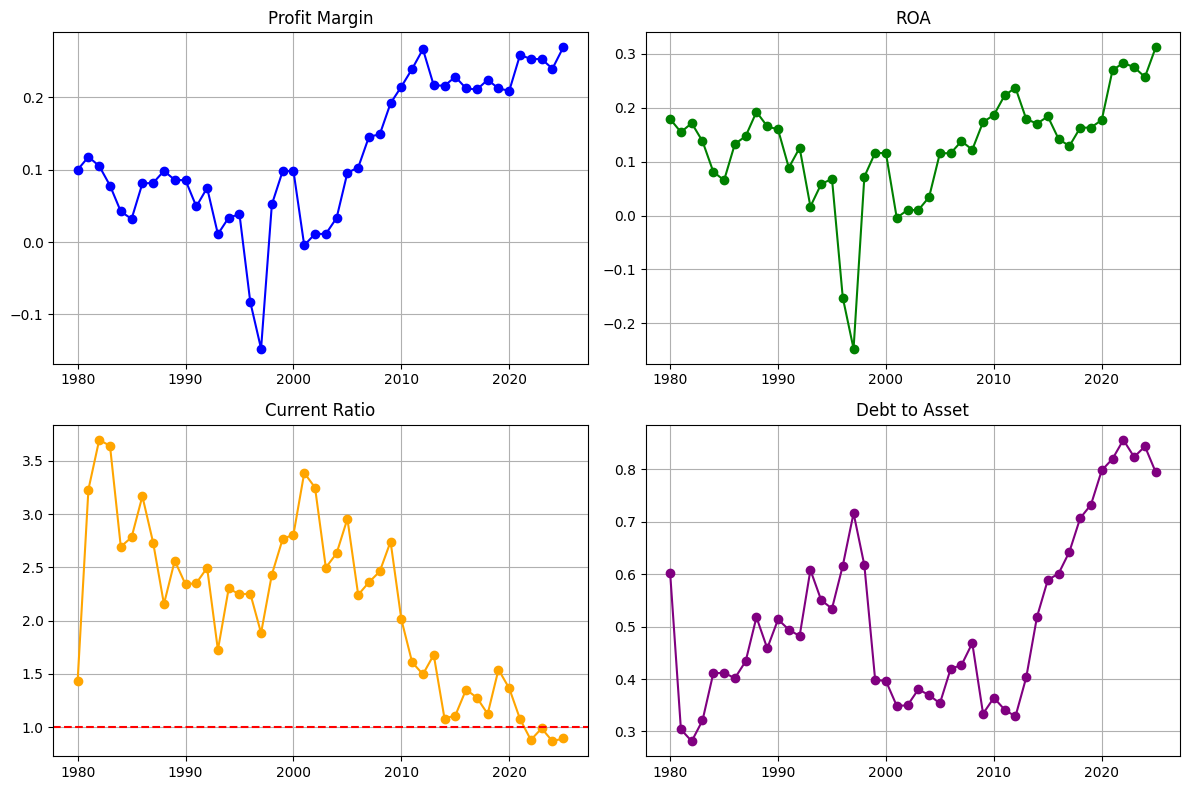


=== Key Accounting Insights ===
1. Profit margin measures Apple’s ability to generate profit from revenue.
2. ROA shows efficiency in using assets to earn income.
3. Current ratio > 1 indicates strong short-term liquidity.
4. Debt-to-asset reflects financial leverage and solvency risk.


In [5]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.plot(df.index, df['profit_margin'], marker='o', color='blue')
plt.title('Profit Margin')
plt.grid(True)

plt.subplot(2,2,2)
plt.plot(df.index, df['roa'], marker='o', color='green')
plt.title('ROA')
plt.grid(True)

plt.subplot(2,2,3)
plt.plot(df.index, df['current_ratio'], marker='o', color='orange')
plt.axhline(1, color='r', linestyle='--')
plt.title('Current Ratio')
plt.grid(True)

plt.subplot(2,2,4)
plt.plot(df.index, df['debt_to_asset'], marker='o', color='purple')
plt.title('Debt to Asset')
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n=== Key Accounting Insights ===")
print("1. Profit margin measures Apple’s ability to generate profit from revenue.")
print("2. ROA shows efficiency in using assets to earn income.")
print("3. Current ratio > 1 indicates strong short-term liquidity.")
print("4. Debt-to-asset reflects financial leverage and solvency risk.")